# Project: Frogs_MFCCs Classification
## Course: Data Science

| Group Members | Student ID |
| :--- | :--- |
| **Kasım Aktaş** | 2230765031 |
| **İlyas Aslan** | 2230765041 |


---
**Date:**  17.01.2026
**Instructor:** Prof. Dr. Nazlı İkizler Cinbiş

# IMPORT

In [12]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import cross_val_predict
from sklearn.model_selection import GroupKFold,cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc ,silhouette_score
from itertools import cycle


# Step 1: Data Collection





In [15]:
file_id = '1vMY2ajWOfrhrpAvtM5huv2NjP7W6k_4s'
url = f'https://drive.google.com/uc?export=download&id={file_id}'


dataset = pd.read_csv(url)
dataset

,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22,Family,Genus,Species,RecordID
0,1.0,0.152936,-0.105586,0.200722,0.317201,0.260764,0.100945,-0.150063,-0.171128,0.124676,...,-0.108351,-0.077623,-0.009568,0.057684,0.118680,0.014038,Leptodactylidae,Adenomera,AdenomeraAndre,1
1,1.0,0.171534,-0.098975,0.268425,0.338672,0.268353,0.060835,-0.222475,-0.207693,0.170883,...,-0.090974,-0.056510,-0.035303,0.020140,0.082263,0.029056,Leptodactylidae,Adenomera,AdenomeraAndre,1
2,1.0,0.152317,-0.082973,0.287128,0.276014,0.189867,0.008714,-0.242234,-0.219153,0.232538,...,-0.050691,-0.023590,-0.066722,-0.025083,0.099108,0.077162,Leptodactylidae,Adenomera,AdenomeraAndre,1
3,1.0,0.224392,0.118985,0.329432,0.372088,0.361005,0.015501,-0.194347,-0.098181,0.270375,...,-0.136009,-0.177037,-0.130498,-0.054766,-0.018691,0.023954,Leptodactylidae,Adenomera,AdenomeraAndre,1
4,1.0,0.087817,-0.068345,0.306967,0.330923,0.249144,0.006884,-0.265423,-0.172700,0.266434,...,-0.048885,-0.053074,-0.088550,-0.031346,0.108610,0.079244,Leptodactylidae,Adenomera,AdenomeraAndre,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7190,1.0,-0.554504,-0.337717,0.035533,0.034511,0.443451,0.093889,-0.100753,0.037087,0.081075,...,0.069430,0.071001,0.021591,0.052449,-0.021860,-0.079860,Hylidae,Scinax,ScinaxRuber,60
7191,1.0,-0.517273,-0.370574,0.030673,0.068097,0.402890,0.096628,-0.116460,0.063727,0.089034,...,0.061127,0.068978,0.017745,0.046461,-0.015418,-0.101892,Hylidae,Scinax,ScinaxRuber,60
7192,1.0,-0.582557,-0.343237,0.029468,0.064179,0.385596,0.114905,-0.103317,0.070370,0.081317,...,0.082474,0.077771,-0.009688,0.027834,-0.000531,-0.080425,Hylidae,Scinax,ScinaxRuber,60
7193,1.0,-0.519497,-0.307553,-0.004922,0.072865,0.377131,0.086866,-0.115799,0.056979,0.089316,...,0.051796,0.069073,0.017963,0.041803,-0.027911,-0.096895,Hylidae,Scinax,ScinaxRuber,60


In [16]:
#We took the data from Google Drive and converted it into a dataset.

# Step 2: Data Preprocessing and Cleaning

MFCCs_ 1    0
MFCCs_ 2    0
MFCCs_ 3    0
MFCCs_ 4    0
MFCCs_ 5    0
MFCCs_ 6    0
MFCCs_ 7    0
MFCCs_ 8    0
MFCCs_ 9    0
MFCCs_10    0
MFCCs_11    0
MFCCs_12    0
MFCCs_13    0
MFCCs_14    0
MFCCs_15    0
MFCCs_16    0
MFCCs_17    0
MFCCs_18    0
MFCCs_19    0
MFCCs_20    0
MFCCs_21    0
MFCCs_22    0
Family      0
Genus       0
Species     0
RecordID    0
dtype: int64

Number of missing values: 0
Original dataset shape: (7195, 23)
Cleaned dataset shape: (5416, 22)
Number of outliers removed: 1779

Correlation matrix of original numeric dataset:


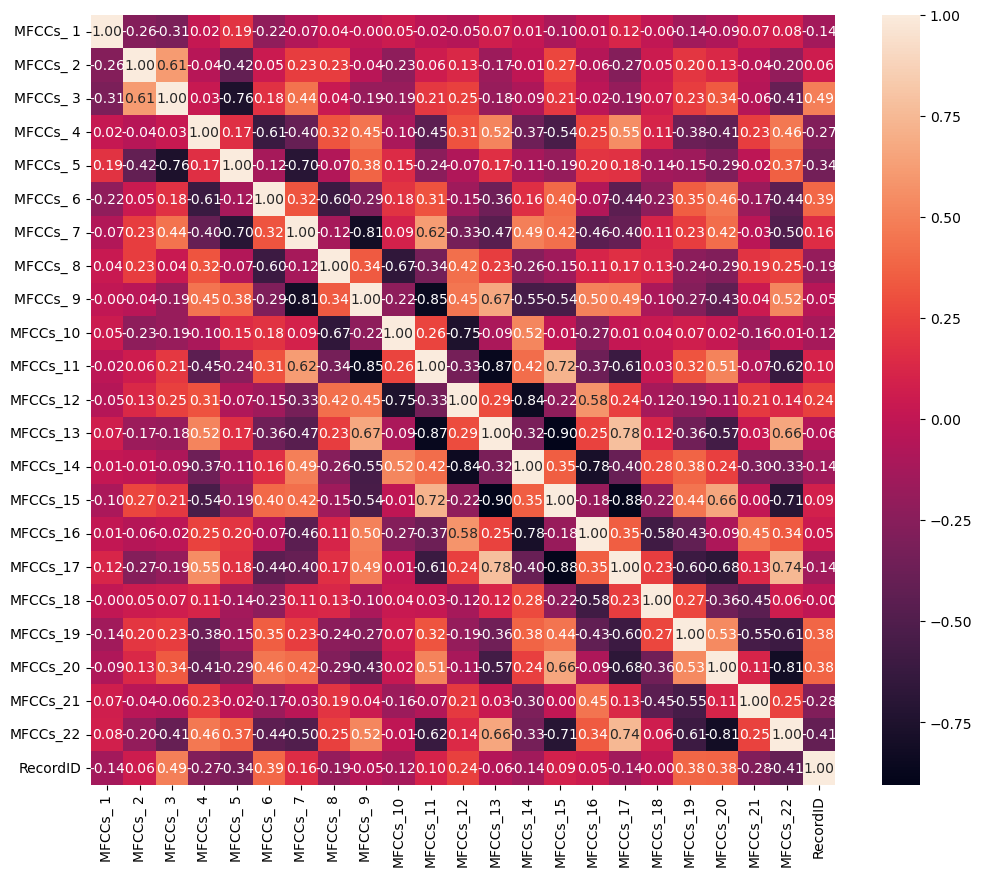


Correlation matrix of cleaned numeric dataset:


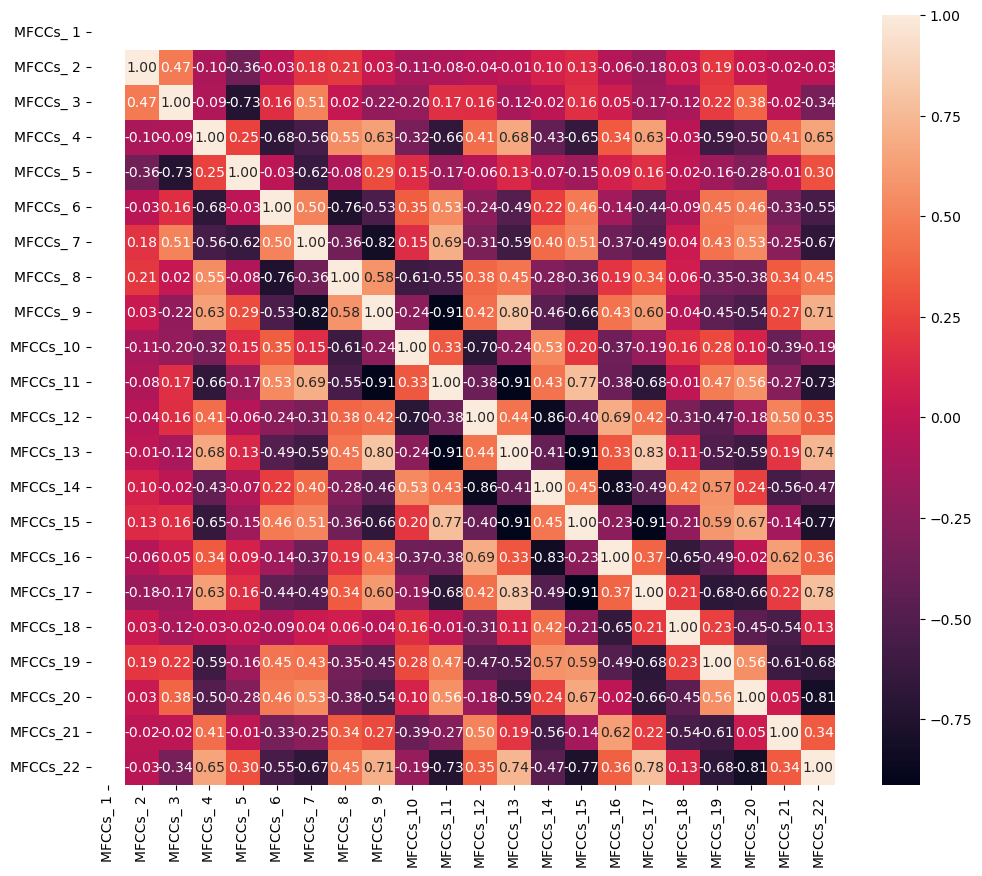

In [18]:
display(dataset.isnull().sum())
print(f"Number of missing values: {dataset.isnull().sum().sum()}")
dataset_numeric=dataset.select_dtypes(include=[np.number])
dataset_numeric.drop(['RecordID'], axis=1)
Q1 = dataset_numeric.quantile(0.25)
Q3 = dataset_numeric.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
outliers = ((dataset_numeric < lower_bound) | (dataset_numeric > upper_bound)).any(axis=1)
cleaned_dataset = dataset[~outliers].copy()
cleaned_dataset_numeric=cleaned_dataset.select_dtypes(include=[np.number])
cleaned_dataset_numeric.drop(['RecordID'], axis=1, inplace=True)
print("Original dataset shape:", dataset_numeric.shape)
print("Cleaned dataset shape:", cleaned_dataset_numeric.shape)
print("Number of outliers removed:", dataset_numeric.shape[0] - cleaned_dataset_numeric.shape[0])
print()

print("Correlation matrix of original numeric dataset:")
plt.figure(figsize=(12,10))
sns.heatmap(dataset_numeric.corr(), annot=True, fmt=".2f")
plt.show()
print()
print("Correlation matrix of cleaned numeric dataset:")
plt.figure(figsize=(12,10))
sns.heatmap(cleaned_dataset_numeric.corr(), annot=True, fmt=".2f")
plt.show()


In [19]:
# There is no missing value in the dataset.
# We seperated the numeric features from the dataset.
# We removed the outliers from the dataset using IQR method.
# Number of outliers removed: 1779
# We also visualized the correlation matrix of the original and cleaned numeric datasets.
# From the correlation matrices, we can say deleting outliers do not create huge impact on the correlation between features.

# Step 3: Data Exploration and Analysis

For n_clusters = 2, The average silhouette_score is : 0.3889535431997599
For n_clusters = 3, The average silhouette_score is : 0.2550705743378293
For n_clusters = 4, The average silhouette_score is : 0.26858683217776846
For n_clusters = 5, The average silhouette_score is : 0.25976049820840397
For n_clusters = 6, The average silhouette_score is : 0.2454423384952695
For n_clusters = 7, The average silhouette_score is : 0.2578492566335953
For n_clusters = 8, The average silhouette_score is : 0.2063573441567877
For n_clusters = 9, The average silhouette_score is : 0.21497428789612277
For n_clusters = 10, The average silhouette_score is : 0.2040143510927743


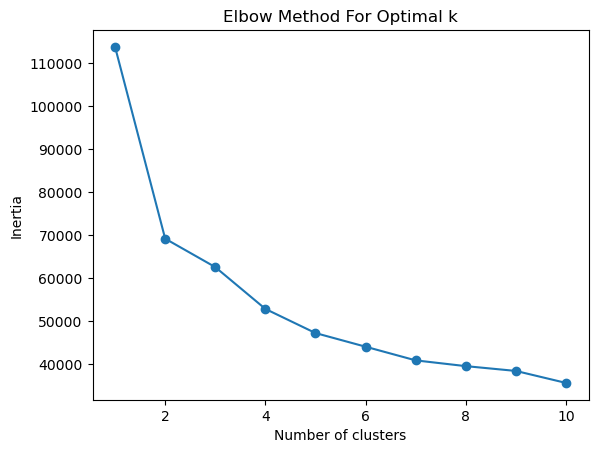

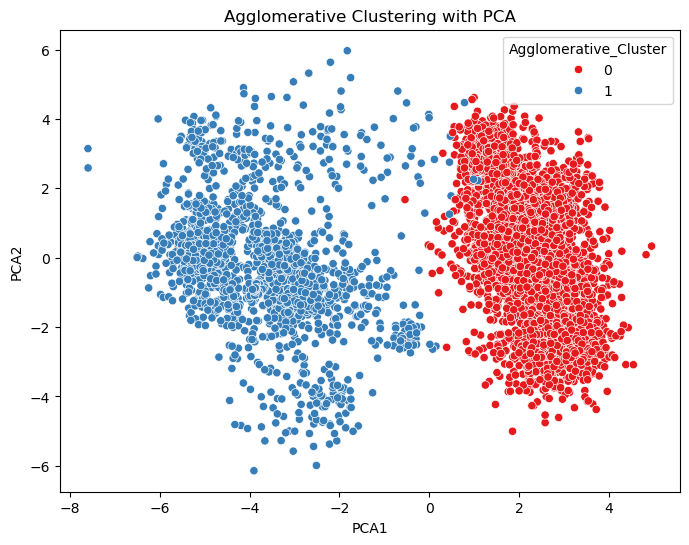

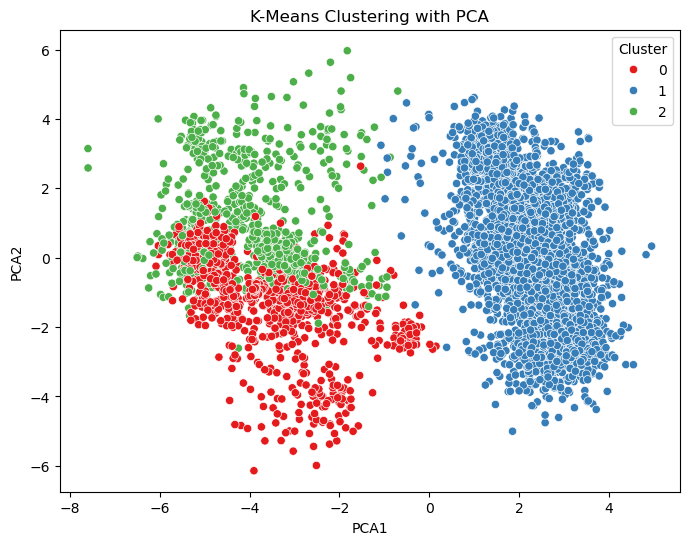

Cluster  Species               
0        HypsiboasCordobae          443
         Ameeregatrivittata         121
         HypsiboasCinerascens       101
         AdenomeraAndre              96
         LeptodactylusFuscus         79
         ScinaxRuber                 76
         Rhinellagranulosa           58
         OsteocephalusOophagus       48
         HylaMinuta                  12
         AdenomeraHylaedactylus       1
1        AdenomeraHylaedactylus    3277
         HylaMinuta                  36
         HypsiboasCordobae            3
2        HypsiboasCordobae          552
         Ameeregatrivittata         271
         HylaMinuta                 117
         AdenomeraAndre              84
         ScinaxRuber                 33
         LeptodactylusFuscus          8
Name: count, dtype: int64

In [20]:
x=cleaned_dataset_numeric
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
inertia=[]
score_silhouette=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, random_state=61)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)
for i in range(2,11):  
    n_clusters = i  
    agg=AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = agg.fit_predict(x_scaled)
    silhouette_avg = silhouette_score(x_scaled, cluster_labels)
    score_silhouette.append(silhouette_avg)
    print(f"For n_clusters = {i}, The average silhouette_score is : {silhouette_avg}") 
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of clusters')    
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()  
clusters_k_means=3
cluster_agglomerative=2
agglomerative=AgglomerativeClustering(n_clusters=cluster_agglomerative,linkage='ward')
kmeans=KMeans(n_clusters=clusters_k_means, random_state=61)
y_agg=agglomerative.fit_predict(x_scaled)
cleaned_dataset['Agglomerative_Cluster']=y_agg

y_kmeans=kmeans.fit_predict(x_scaled)
cleaned_dataset['Cluster']=y_kmeans
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)
cleaned_dataset['PCA1']=x_pca[:,0]
cleaned_dataset['PCA2']=x_pca[:,1]
plt.figure(figsize=(8,6))
sns.scatterplot(x="PCA1", y="PCA2", hue='Agglomerative_Cluster', data=cleaned_dataset, palette='Set1')
plt.title('Agglomerative Clustering with PCA')
plt.show()
plt.figure(figsize=(8,6))
sns.scatterplot(x="PCA1", y="PCA2", hue='Cluster', data=cleaned_dataset, palette='Set1')
plt.title('K-Means Clustering with PCA')
plt.show()
display(cleaned_dataset.groupby('Cluster')["Species"].value_counts())


In [21]:
# We applied K-Means and Agglomerative Clustering algorithms to the cleaned dataset.
# Using the Elbow Method and Silhouette Score, we determined the optimal number of clusters for K-Means (3) and Agglomerative Clustering (2).
# We visualized the clusters using PCA.
# Some species are grouped together in the same cluster. Because they share similar characteristics.
# The results show that the clustering algorithms were able to group similar species together effectively.

# Step 4: Predictive Modelling

In [22]:
x=cleaned_dataset.drop(['RecordID', 'Species', 'Genus', 'Family', 'PCA1', 'PCA2', 'Cluster'], axis=1)
y=cleaned_dataset['Species']
groups=cleaned_dataset['RecordID']
gb=GroupKFold(n_splits=5)
le=LabelEncoder()
y_encoded=le.fit_transform(y)
scores=[]
f1_scores=[]
scorings=["accuracy", "f1_weighted"]
for k in range(1,11):
    knn=KNeighborsClassifier(n_neighbors=k)
    cross_val_scores= cross_validate(knn, x_scaled, y_encoded, groups=groups, cv=gb, scoring=scorings)
    scores.append(cross_val_scores["test_accuracy"].mean())
    f1_scores.append(cross_val_scores["test_f1_weighted"].mean())

for i, score in enumerate(scores, start=1):
    print(f'k={i}, Validation Accuracy={score:.4f}')
    print(f'k={i}, Validation F1-Score={f1_scores[i-1]:.4f}')
print()    
optimal_k=5    

knn=KNeighborsClassifier(n_neighbors=optimal_k)
cross_val_scores= cross_validate(knn, x_scaled, y_encoded, groups=groups, cv=gb, scoring=scorings)
print("Cross-Validation Scores for KNN:", cross_val_scores["test_accuracy"])
print("Mean Cross-Validation Score for KNN:", np.mean(cross_val_scores['test_accuracy']))
print("Cross-Validation F1 Scores for KNN:", cross_val_scores["test_f1_weighted"].mean())
print()
dtc=DecisionTreeClassifier(random_state=61)
cross_val_scores= cross_validate(dtc, x_scaled, y_encoded, groups=groups, cv=gb, scoring=scorings)
print("Cross-Validation Scores for Decision Tree:", cross_val_scores["test_accuracy"])
print("Mean Cross-Validation Score for Decision Tree:", np.mean(cross_val_scores['test_accuracy']))
print("Cross-Validation F1 Scores for Decision Tree:", cross_val_scores["test_f1_weighted"].mean())
print()
lr=LogisticRegression(max_iter=1000, random_state=61,class_weight='balanced')
cross_val_scores= cross_validate(lr, x_scaled, y_encoded, groups=groups, cv=gb, scoring=scorings)
print("Cross-Validation Scores for Logistic Regression:", cross_val_scores["test_accuracy"])
print("Mean Cross-Validation Score for Logistic Regression:", np.mean(cross_val_scores['test_accuracy']))
print("Cross-Validation F1 Scores for Logistic Regression:", cross_val_scores["test_f1_weighted"].mean())   

k=1, Validation Accuracy=0.9213
k=1, Validation F1-Score=0.9295
k=2, Validation Accuracy=0.9234
k=2, Validation F1-Score=0.9281
k=3, Validation Accuracy=0.9199
k=3, Validation F1-Score=0.9265
k=4, Validation Accuracy=0.9193
k=4, Validation F1-Score=0.9259
k=5, Validation Accuracy=0.9189
k=5, Validation F1-Score=0.9266
k=6, Validation Accuracy=0.9188
k=6, Validation F1-Score=0.9257
k=7, Validation Accuracy=0.9171
k=7, Validation F1-Score=0.9249
k=8, Validation Accuracy=0.9162
k=8, Validation F1-Score=0.9234
k=9, Validation Accuracy=0.9145
k=9, Validation F1-Score=0.9219
k=10, Validation Accuracy=0.9134
k=10, Validation F1-Score=0.9205

Cross-Validation Scores for KNN: [0.95110701 0.94921514 0.77469991 0.97691597 0.94275162]
Mean Cross-Validation Score for KNN: 0.9189379303765337
Cross-Validation F1 Scores for KNN: 0.9265739577183764

Cross-Validation Scores for Decision Tree: [0.85055351 0.8744229  0.71375808 0.94367498 0.93721145]
Mean Cross-Validation Score for Decision Tree: 0.863924

In [23]:
# We evaluated KNN, Decision Tree, and Logistic Regression classifiers using Group K-Fold Cross-Validation.
# There no significinat difference between the F1-scores of KNN for each k value from 1 to 10. So we chose k=5.
# We chose Group K-Fold to ensure that data points from the same group (RecordID) are not split between training and validation sets, preventing data overfit.
# KNN achieved the highest mean accuracy and F1 scores, followed by Logistic Regression, and Decision Tree. So, we use KNN as the best model for this dataset.
# But there is no significant difference between the KNN and Logistic Regression models.

# Step 5: Model Evaluation and Visualizations

Classification Report for KNN:
                         precision    recall  f1-score   support

        AdenomeraAndre       0.71      0.40      0.51       180
AdenomeraHylaedactylus       1.00      1.00      1.00      3278
    Ameeregatrivittata       0.88      0.57      0.69       392
            HylaMinuta       0.88      0.72      0.79       165
  HypsiboasCinerascens       0.88      0.83      0.86       101
     HypsiboasCordobae       0.90      0.99      0.95       998
   LeptodactylusFuscus       0.98      0.67      0.79        87
 OsteocephalusOophagus       0.13      0.29      0.18        48
     Rhinellagranulosa       0.31      0.98      0.47        58
           ScinaxRuber       0.93      0.78      0.85       109

              accuracy                           0.92      5416
             macro avg       0.76      0.72      0.71      5416
          weighted avg       0.94      0.92      0.92      5416



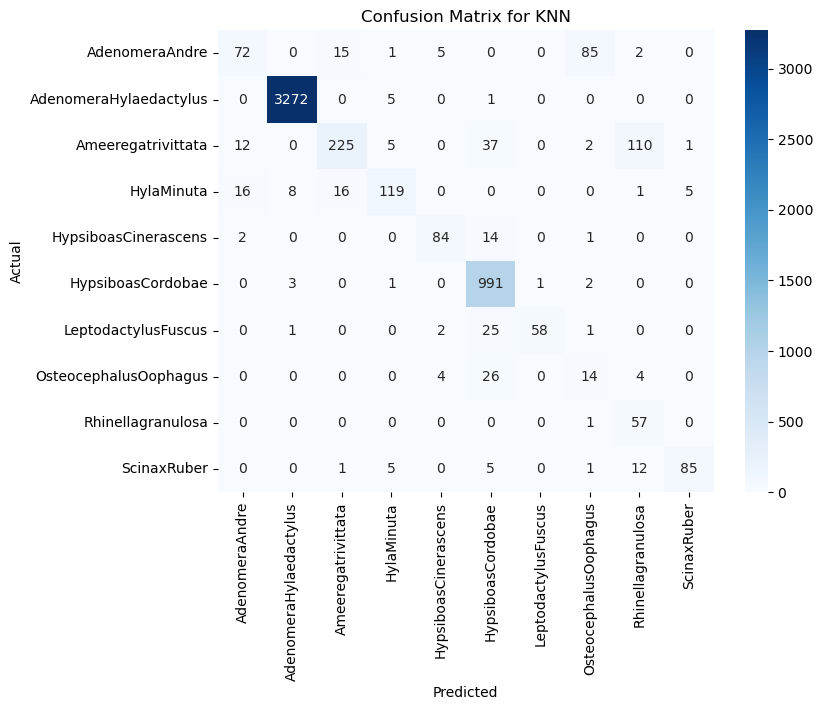

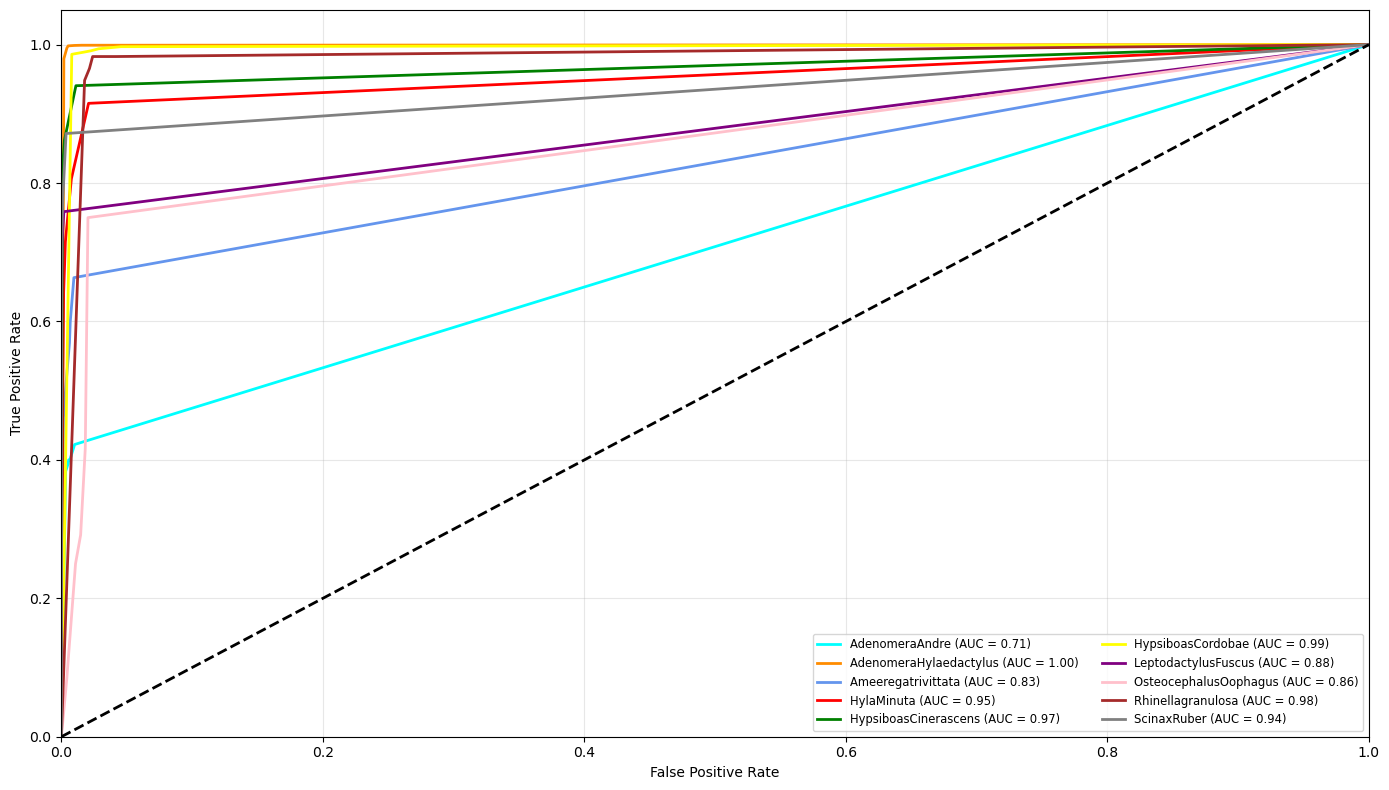

In [24]:
y_pred_knn= cross_val_predict(knn, x_scaled, y_encoded, groups=groups, cv=gb)
print("Classification Report for KNN:\n", classification_report(y_encoded, y_pred_knn, target_names=le.classes_))   
cm=confusion_matrix(y_encoded, y_pred_knn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN')
plt.show() 

plt.figure(figsize=(14, 8))
y_probas = cross_val_predict(knn, x_scaled, y_encoded, groups=groups, cv=gb, method='predict_proba')
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'yellow', 'purple', 'pink', 'brown', 'gray'])
for i, color in zip(range(len(le.classes_)), colors):
    fpr, tpr, _ = roc_curve((y_encoded == i).astype(int), y_probas[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
# We showed the classification report, confusion matrix, and ROC curves for the KNN classifier.
# The species of AdenomeraHylaedactylus is gives the highest accuracy and F1-score among all species. This is most likely because there are many instances of this type, and other types are similar to it, allowing the model to predict it very well.
# Some species like OsteocephalusOophagus  have lower accuracy and F1-scores, possibly due to fewer instances or similarity to other species, leading to misclassifications.